In [4]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time


from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                           roc_curve, roc_auc_score, precision_score, recall_score, f1_score)
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc


In [5]:

# Mount Google Drive and load data (Colab)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
print("Loading datasets...")
# Load NSL-KDD (flexible column handling)
file_path = "/content/drive/MyDrive/DoS-Wednesday-no-metadata.parquet"


Loading datasets...


In [7]:
df = pd.read_parquet(file_path)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())

Dataset shape: (584991, 78)

First 5 rows:
   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         6          38308                  1                       1   
1         6            479                 11                       5   
2         6           1095                 10                       6   
3         6          15206                 17                      12   
4         6           1092                  9                       6   

   Fwd Packets Length Total  Bwd Packets Length Total  Fwd Packet Length Max  \
0                         6                         6                      6   
1                       172                       326                     79   
2                      3150                      3150                   1575   
3                      3452                      6660                   1313   
4                      3150                      3152                   1575   

   Fwd Packet Length Min  Fwd Packet 

In [8]:
# Check and drop missing values if any
print("Missing values in dataset:", df.isnull().sum().sum())
if df.isnull().sum().sum() > 0:
    df.dropna(inplace=True)
    print("Missing values dropped")

# Remove duplicates
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {before - df.shape[0]} duplicates. New shape: {df.shape}")

Missing values in dataset: 0
Removed 0 duplicates. New shape: (584991, 78)


Class distribution:
attack_binary
0    391235
1    193756
Name: count, dtype: int64

Class distribution (%):
attack_binary
0    66.878807
1    33.121193
Name: proportion, dtype: float64


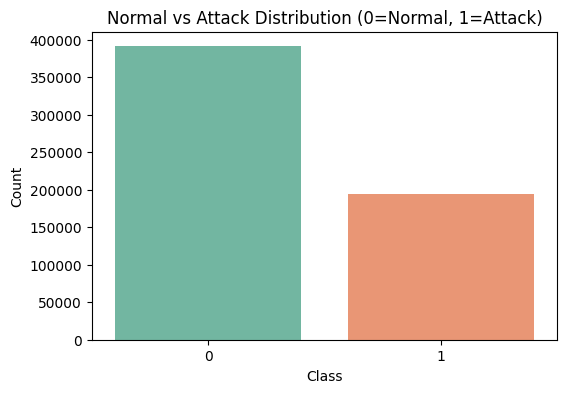

In [9]:
# Create binary target variable: 0 = Benign, 1 = Attack
df['attack_binary'] = df['Label'].apply(lambda x: 0 if str(x).lower() == 'benign' else 1)

# Check class distribution
print("Class distribution:")
print(df['attack_binary'].value_counts())
print("\nClass distribution (%):")
print(df['attack_binary'].value_counts(normalize=True) * 100)

# Plot class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='attack_binary', data=df, hue='attack_binary', palette="Set2", legend=False)
plt.title("Normal vs Attack Distribution (0=Normal, 1=Attack)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

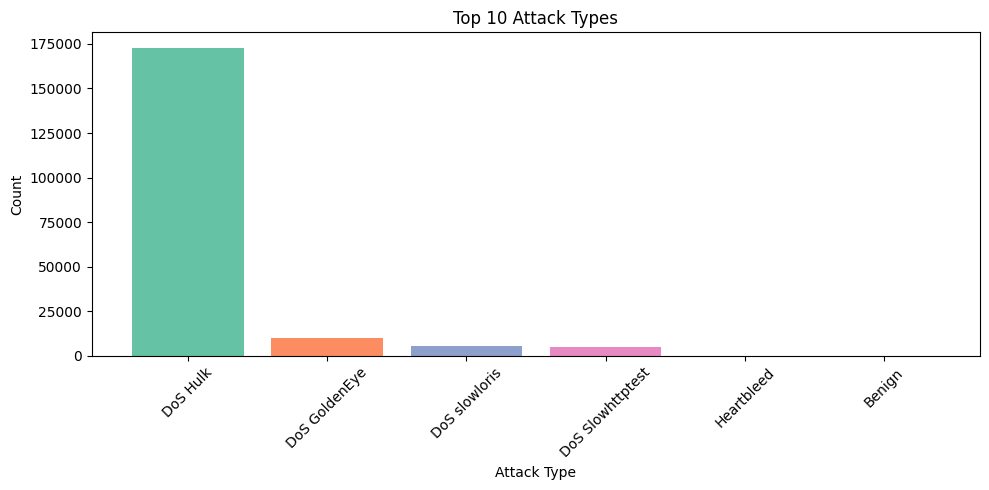

In [10]:
# Top 10 attack types plot
attack_counts = df[df['Label'].str.lower() != 'benign']['Label'].value_counts().head(10)

plt.figure(figsize=(10,5))
bars = plt.bar(attack_counts.index, attack_counts.values)
colors = sns.color_palette("Set2", len(attack_counts))
for i, bar in enumerate(bars):
    bar.set_facecolor(colors[i])

plt.title("Top 10 Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Identify categorical columns except 'Label' and target
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['Label', 'attack_binary']]

print("Categorical columns to encode:", categorical_cols)

# One-hot encode categorical columns if any exist
if categorical_cols:
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print(f"Shape after encoding: {df_encoded.shape}")
else:
    df_encoded = df.copy()
    print("No categorical columns to encode")

# Prepare features and target
exclude_cols = ['Label', 'attack_binary']
X = df_encoded.drop(columns=exclude_cols)
y = df_encoded['attack_binary']

print("Feature columns:", len(X.columns))
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Categorical columns to encode: []
No categorical columns to encode
Feature columns: 77
Features shape: (584991, 77)
Target shape: (584991,)


In [12]:
# Scale features using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print("Features scaled successfully")
print("Scaled features range:")
print(f"Min: {X_scaled.min().min():.3f}")
print(f"Max: {X_scaled.max().max():.3f}")

Features scaled successfully
Scaled features range:
Min: 0.000
Max: 1.000


In [13]:
X = df.drop(columns=exclude_cols)
y = df['attack_binary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)


Train set: (467992, 77)
Test set: (116999, 77)


In [14]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)
print("Train class distribution:")
print(y_train.value_counts(normalize=True))

Train set: (467992, 77)
Test set: (116999, 77)
Train class distribution:
attack_binary
0    0.668787
1    0.331213
Name: proportion, dtype: float64


In [15]:
# Train-validation split for model selection
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Training set:", X_train_final.shape)
print("Validation set:", X_val.shape)

Training set: (374393, 77)
Validation set: (93599, 77)


In [19]:
# Initial model validation
initial_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

print("\n=== Initial Model Validation ===")
for name, model in initial_models.items():
    start_time = time.time()
    model.fit(X_train_final, y_train_final)
    end_time = time.time()

    y_val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)

    cm = confusion_matrix(y_val, y_val_pred)
    TN, FP, FN, TP = cm.ravel()
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    training_time = end_time - start_time

    print(f"\n{name}:")
    print(f"  Validation Accuracy: {val_acc * 100:.2f}%")
    print(f"  Specificity: {specificity:.4f}")
    print(f"  Training Time: {training_time:.4f} seconds")


=== Initial Model Validation ===

Logistic Regression:
  Validation Accuracy: 97.21%
  Specificity: 0.9933
  Training Time: 16.5215 seconds

Decision Tree:
  Validation Accuracy: 99.92%
  Specificity: 0.9993
  Training Time: 33.2654 seconds

Random Forest:
  Validation Accuracy: 99.86%
  Specificity: 0.9990
  Training Time: 156.4034 seconds

Gradient Boosting:
  Validation Accuracy: 99.70%
  Specificity: 0.9991
  Training Time: 640.7236 seconds


In [20]:
# Optimized models with better hyperparameters
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced",
        C=0.5
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=120,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced_subsample"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,
        n_estimators=150,
        learning_rate=0.1,
        max_depth=3
    )
}

# Training and testing evaluation
print("\n=== Final Model Evaluation ===")
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    # Training accuracy
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    print(f"{name} Training Accuracy: {train_acc * 100:.2f}%")

    # Testing accuracy
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    results[name] = test_acc
    print(f"{name} Testing Accuracy: {test_acc * 100:.2f}%")

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))


=== Final Model Evaluation ===

Training Logistic Regression...
Logistic Regression Training Accuracy: 96.91%
Logistic Regression Testing Accuracy: 97.04%

Logistic Regression Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98     78248
      Attack       0.94      0.98      0.96     38751

    accuracy                           0.97    116999
   macro avg       0.96      0.97      0.97    116999
weighted avg       0.97      0.97      0.97    116999


Training Decision Tree...
Decision Tree Training Accuracy: 99.06%
Decision Tree Testing Accuracy: 99.08%

Decision Tree Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     78248
      Attack       0.99      0.98      0.99     38751

    accuracy                           0.99    116999
   macro avg       0.99      0.99      0.99    116999
weighted avg       0.99      0.99      0.99    116999


T

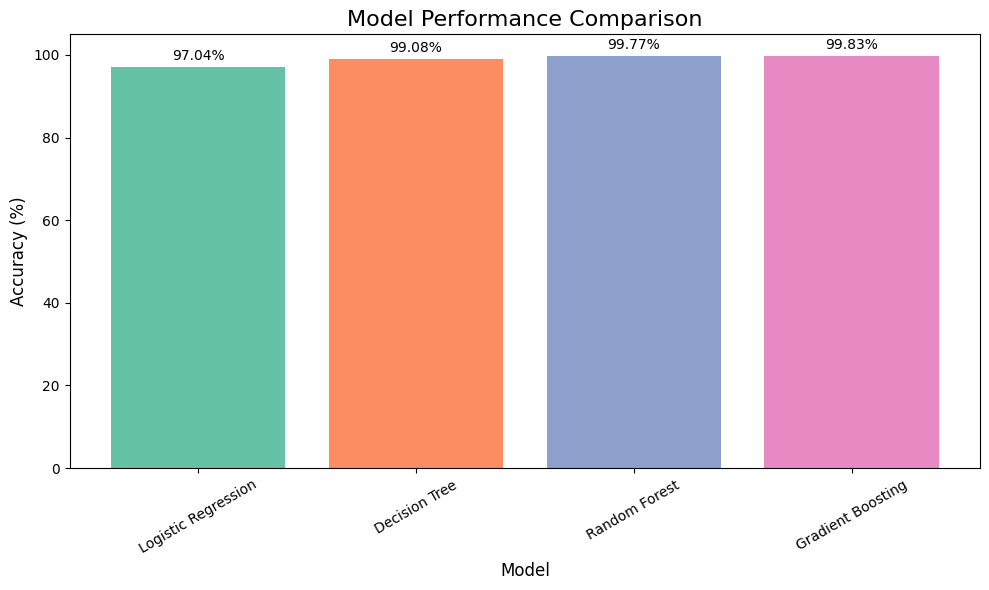


=== Performance Summary ===
Logistic Regression: 97.04%
Decision Tree: 99.08%
Random Forest: 99.77%
Gradient Boosting: 99.83%


In [21]:
# Accuracy barplot with percentage values
results_df = pd.DataFrame([
    {'Model': name, 'Accuracy': acc * 100}
    for name, acc in results.items()
])

plt.figure(figsize=(10, 6))
bars = plt.bar(results_df['Model'], results_df['Accuracy'])

# Apply Set2 colors
colors = sns.color_palette("Set2", len(results_df))
for i, bar in enumerate(bars):
    bar.set_facecolor(colors[i])

plt.title('Model Performance Comparison', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 105)
plt.xticks(rotation=30)

# Add accuracy labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print performance summary
print("\n=== Performance Summary ===")
for name, acc in results.items():
    print(f"{name}: {acc*100:.2f}%")


=== Best Model: Gradient Boosting ===
Test Accuracy: 0.9983 (99.83%)


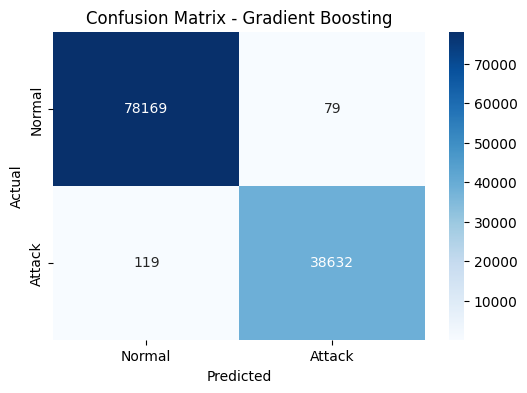


Detailed Metrics for Gradient Boosting:
True Negatives (Normal correctly identified): 78169
False Positives (Normal misclassified as Attack): 79
False Negatives (Attack misclassified as Normal): 119
True Positives (Attack correctly identified): 38632

Calculated Metrics:
Accuracy: 0.9983 (99.83%)
Precision: 0.9980
Recall (Sensitivity): 0.9969
Specificity: 0.9990


In [22]:
# Select best performing model
best_model_name = max(results.keys(), key=lambda k: results[k])
best_model = models[best_model_name]
best_accuracy = results[best_model_name]

print(f"\n=== Best Model: {best_model_name} ===")
print(f"Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# Generate predictions with best model
y_pred_best = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Calculate metrics from confusion matrix
if cm.shape == (2, 2):
    TN, FP, FN, TP = cm.ravel()

    accuracy_cm = (TN + TP) / (TN + FP + FN + TP)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    print(f"\nDetailed Metrics for {best_model_name}:")
    print(f"True Negatives (Normal correctly identified): {TN}")
    print(f"False Positives (Normal misclassified as Attack): {FP}")
    print(f"False Negatives (Attack misclassified as Normal): {FN}")
    print(f"True Positives (Attack correctly identified): {TP}")

    print(f"\nCalculated Metrics:")
    print(f"Accuracy: {accuracy_cm:.4f} ({accuracy_cm*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")

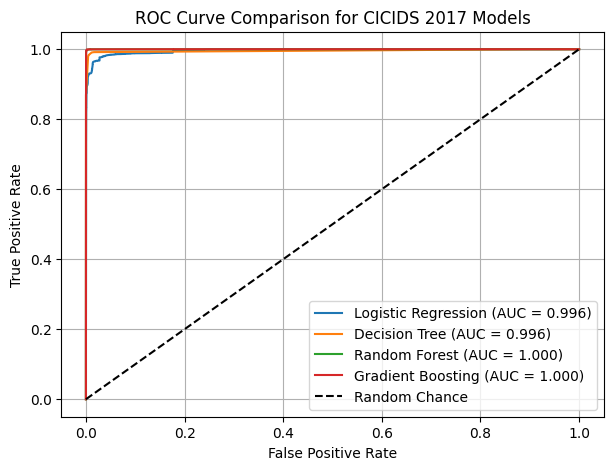

In [23]:
# ROC Curve Comparison
plt.figure(figsize=(7, 5))

for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curve Comparison for CICIDS 2017 Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

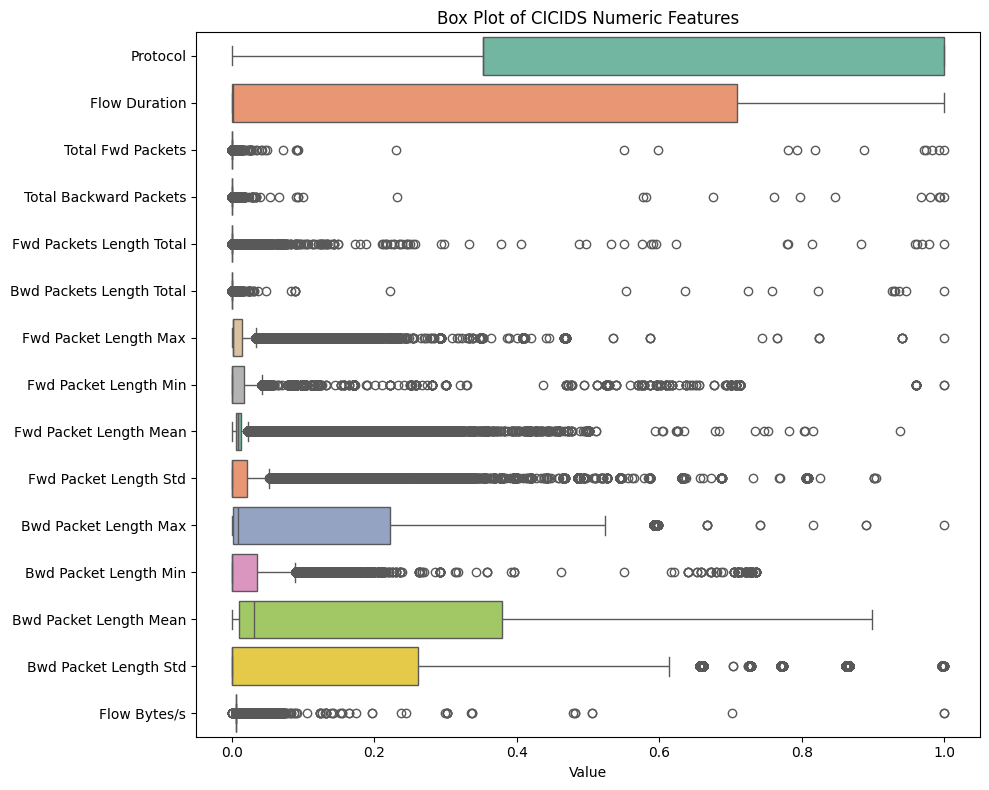

In [24]:
# Box plot of numeric features
numeric_cols_cicids = X_train.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(10, 8))
subset_cols = numeric_cols_cicids[:15]
sns.boxplot(data=X_train[subset_cols], orient='h', palette="Set2")
plt.title('Box Plot of CICIDS Numeric Features')
plt.xlabel('Value')
plt.tight_layout()
plt.show()

In [25]:
# Multi-Class Classification
print("===MULTI-CLASS CLASSIFICATION===")

# Prepare multi-class data
X_train_multi = X_train  # Use same scaled training features
y_train_multi = df_encoded.loc[X_train.index, 'Label']  # Original multi-class labels

X_test_multi = X_test  # Use same scaled test features
y_test_multi = df_encoded.loc[X_test.index, 'Label']  # Original multi-class labels

print("Multi-class distribution in training set:")
print(y_train_multi.value_counts())
print("\nMulti-class distribution in test set:")
print(y_test_multi.value_counts())

# Multi-class train-validation split
X_train_mc, X_val_mc, y_train_mc, y_val_mc = train_test_split(
    X_train_multi, y_train_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_train_multi
)

print(f"\nMulti-class training shape: {X_train_mc.shape}")
print(f"Multi-class validation shape: {X_val_mc.shape}")
print(f"Multi-class test shape: {X_test_multi.shape}")

===MULTI-CLASS CLASSIFICATION===
Multi-class distribution in training set:
Label
Benign              312987
DoS Hulk            138337
DoS GoldenEye         8253
DoS slowloris         4254
DoS Slowhttptest      4153
Heartbleed               8
Name: count, dtype: int64

Multi-class distribution in test set:
Label
Benign              78248
DoS Hulk            34509
DoS GoldenEye        2033
DoS slowloris        1131
DoS Slowhttptest     1075
Heartbleed              3
Name: count, dtype: int64

Multi-class training shape: (374393, 77)
Multi-class validation shape: (93599, 77)
Multi-class test shape: (116999, 77)


In [26]:
# Optimized multi-class models with faster parameters
multi_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=500,
        random_state=42,
        C=0.5,
        class_weight="balanced"
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=50,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,
        n_estimators=50,
        learning_rate=0.15,
        max_depth=4,
        subsample=0.8
    )
}

In [27]:
# Multi-class model validation function
def validate_multi_models(models, X_train, y_train, X_val, y_val):
    print("\n=== Multi-Class Validation ===")
    validation_results = {}

    for i, (name, model) in enumerate(models.items(), 1):
        print(f"\n[{i}/{len(models)}] Training {name} for multi-class...")
        start_time = time.time()

        # Fit model
        model.fit(X_train, y_train)
        training_time = time.time() - start_time

        # Validation predictions
        y_val_pred = model.predict(X_val)
        val_accuracy = accuracy_score(y_val, y_val_pred)

        # Training predictions (to check overfitting)
        y_train_pred = model.predict(X_train)
        train_accuracy = accuracy_score(y_train, y_train_pred)

        # Store results
        validation_results[name] = {
            'train_accuracy': train_accuracy,
            'val_accuracy': val_accuracy,
            'training_time': training_time
        }

        # Print results
        print(f"{name} Results:")
        print(f"  Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
        print(f"  Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
        print(f"  Training Time: {training_time:.2f} seconds")
        print(f"  Overfitting Check: {abs(train_accuracy - val_accuracy):.4f}")

    return validation_results

# Run multi-class validation
multi_validation_results = validate_multi_models(multi_models, X_train_mc, y_train_mc, X_val_mc, y_val_mc)


=== Multi-Class Validation ===

[1/4] Training Logistic Regression for multi-class...
Logistic Regression Results:
  Training Accuracy: 0.9412 (94.12%)
  Validation Accuracy: 0.9401 (94.01%)
  Training Time: 61.10 seconds
  Overfitting Check: 0.0010

[2/4] Training Decision Tree for multi-class...
Decision Tree Results:
  Training Accuracy: 0.9940 (99.40%)
  Validation Accuracy: 0.9939 (99.39%)
  Training Time: 13.83 seconds
  Overfitting Check: 0.0001

[3/4] Training Random Forest for multi-class...
Random Forest Results:
  Training Accuracy: 0.9883 (98.83%)
  Validation Accuracy: 0.9882 (98.82%)
  Training Time: 57.07 seconds
  Overfitting Check: 0.0001

[4/4] Training Gradient Boosting for multi-class...
Gradient Boosting Results:
  Training Accuracy: 0.9991 (99.91%)
  Validation Accuracy: 0.9988 (99.88%)
  Training Time: 2098.44 seconds
  Overfitting Check: 0.0003


In [29]:
# Multi-class detailed metrics evaluation for all models
def evaluate_multi_detailed_metrics(models, X_train, y_train, X_test, y_test):
    print("\n=== Multi-Class Detailed Metrics Evaluation ===")
    detailed_results = {}

    for name, model in models.items():
        print(f"MODEL: {name}")

        # Train model
        model.fit(X_train, y_train)

        # Test predictions
        y_test_pred = model.predict(X_test)

        # Calculate basic accuracy
        test_accuracy = accuracy_score(y_test, y_test_pred)

        # Calculate detailed metrics
        precision_macro = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
        recall_macro = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
        f1_macro = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

        precision_weighted = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
        recall_weighted = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
        f1_weighted = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

        # Store results
        detailed_results[name] = {
            'accuracy': test_accuracy,
            'precision_macro': precision_macro,
            'recall_macro': recall_macro,
            'f1_macro': f1_macro,
            'precision_weighted': precision_weighted,
            'recall_weighted': recall_weighted,
            'f1_weighted': f1_weighted
        }

        # Print results
        print(f"Testing Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
        print(f"\nMacro Averages:")
        print(f"  Precision: {precision_macro:.4f} ({precision_macro*100:.2f}%)")
        print(f"  Recall:    {recall_macro:.4f} ({recall_macro*100:.2f}%)")
        print(f"  F1-Score:  {f1_macro:.4f} ({f1_macro*100:.2f}%)")
        print(f"\nWeighted Averages:")
        print(f"  Precision: {precision_weighted:.4f} ({precision_weighted*100:.2f}%)")
        print(f"  Recall:    {recall_weighted:.4f} ({recall_weighted*100:.2f}%)")
        print(f"  F1-Score:  {f1_weighted:.4f} ({f1_weighted*100:.2f}%)")

        # Detailed classification report
        print(f"\nDetailed Classification Report:")
        print(classification_report(y_test, y_test_pred, digits=4))

    return detailed_results

# Run detailed metrics evaluation
multi_detailed_results = evaluate_multi_detailed_metrics(multi_models, X_train_mc, y_train_mc, X_test_multi, y_test_multi)


=== Multi-Class Detailed Metrics Evaluation ===
MODEL: Logistic Regression
Testing Accuracy: 0.9421 (94.21%)

Macro Averages:
  Precision: 0.6568 (65.68%)
  Recall:    0.9694 (96.94%)
  F1-Score:  0.7584 (75.84%)

Weighted Averages:
  Precision: 0.9597 (95.97%)
  Recall:    0.9421 (94.21%)
  F1-Score:  0.9473 (94.73%)

Detailed Classification Report:
                  precision    recall  f1-score   support

          Benign     0.9937    0.9214    0.9562     78248
   DoS GoldenEye     0.6782    0.9902    0.8050      2033
        DoS Hulk     0.9341    0.9853    0.9590     34509
DoS Slowhttptest     0.4237    0.9656    0.5889      1075
   DoS slowloris     0.4112    0.9540    0.5747      1131
      Heartbleed     0.5000    1.0000    0.6667         3

        accuracy                         0.9421    116999
       macro avg     0.6568    0.9694    0.7584    116999
    weighted avg     0.9597    0.9421    0.9473    116999

MODEL: Decision Tree
Testing Accuracy: 0.9941 (99.41%)

Macro A

In [30]:
# Multi-class final test evaluation
def evaluate_multi_final_test(models, X_train, y_train, X_test, y_test):
    print("\n=== Multi-Class Final Test Evaluation ===")
    test_results = {}

    for name, model in models.items():
        print(f"\nEvaluating {name}...")

        # Train on full training data
        model.fit(X_train, y_train)

        # Training accuracy
        y_train_pred = model.predict(X_train)
        train_accuracy = accuracy_score(y_train, y_train_pred)

        # Test accuracy
        y_test_pred = model.predict(X_test)
        test_accuracy = accuracy_score(y_test, y_test_pred)

        # Store results
        test_results[name] = test_accuracy

        print(f"{name} Training Accuracy: {train_accuracy*100:.2f}%")
        print(f"{name} Testing Accuracy: {test_accuracy*100:.2f}%")

    return test_results

# Run multi-class final test evaluation
multi_test_results = evaluate_multi_final_test(multi_models, X_train_mc, y_train_mc, X_test_multi, y_test_multi)


=== Multi-Class Final Test Evaluation ===

Evaluating Logistic Regression...
Logistic Regression Training Accuracy: 94.12%
Logistic Regression Testing Accuracy: 94.21%

Evaluating Decision Tree...
Decision Tree Training Accuracy: 99.40%
Decision Tree Testing Accuracy: 99.41%

Evaluating Random Forest...
Random Forest Training Accuracy: 98.83%
Random Forest Testing Accuracy: 98.82%

Evaluating Gradient Boosting...
Gradient Boosting Training Accuracy: 99.91%
Gradient Boosting Testing Accuracy: 99.88%


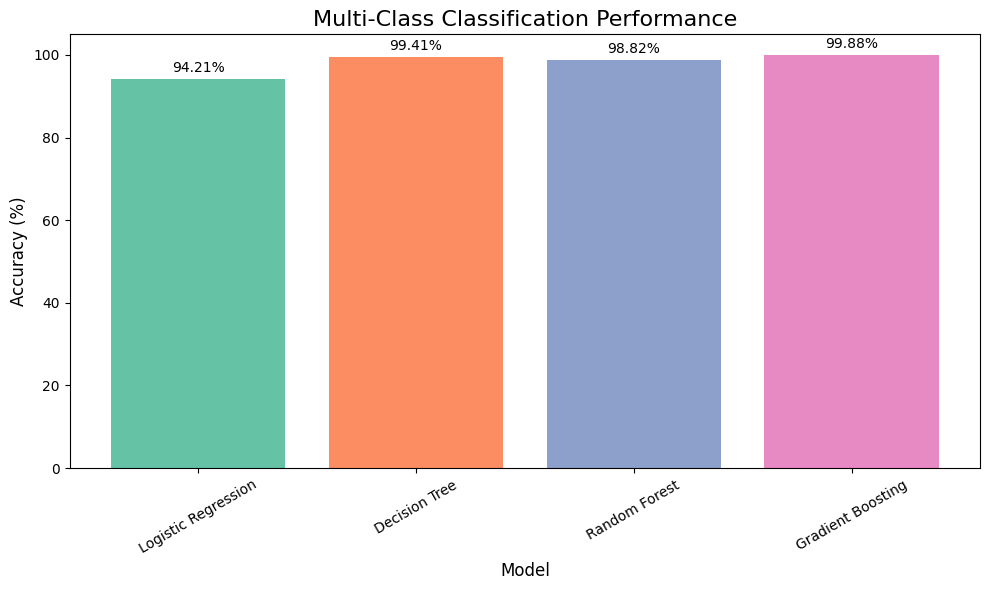


=== Multi-Class Performance Summary ===
Logistic Regression: 94.21%
Decision Tree: 99.41%
Random Forest: 98.82%
Gradient Boosting: 99.88%


In [31]:
# Multi-class performance visualization
multi_results_df = pd.DataFrame([
    {'Model': name, 'Accuracy': acc * 100}
    for name, acc in multi_test_results.items()
])

plt.figure(figsize=(10, 6))
bars = plt.bar(multi_results_df['Model'], multi_results_df['Accuracy'])

# Apply Set3 colors for multi-class (different from binary)
colors = sns.color_palette("Set2", len(multi_results_df))
for i, bar in enumerate(bars):
    bar.set_facecolor(colors[i])

plt.title('Multi-Class Classification Performance', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 105)
plt.xticks(rotation=30)

# Add accuracy labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print multi-class summary
print("\n=== Multi-Class Performance Summary ===")
for name, acc in multi_test_results.items():
    print(f"{name}: {acc*100:.2f}%")

In [ ]:
# Multi-class confusion matrix for best performing model
best_multi_model_name = max(multi_test_results.keys(), key=lambda k: multi_test_results[k])
best_multi_model = multi_models[best_multi_model_name]
best_multi_accuracy = multi_test_results[best_multi_model_name]

print(f"\n=== Best Multi-Class Model: {best_multi_model_name} ===")
print(f"Test Accuracy: {best_multi_accuracy:.4f} ({best_multi_accuracy*100:.2f}%)")

# Train the best multi-class model
best_multi_model.fit(X_train_mc, y_train_mc)

# Generate predictions
y_pred_multi_best = best_multi_model.predict(X_test_multi)

# Multi-class confusion matrix
cm_multi = confusion_matrix(y_test_multi, y_pred_multi_best)

# Get unique class labels for proper labeling
class_labels = sorted(y_test_multi.unique())

plt.figure(figsize=(10, 8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title(f'Multi-Class Confusion Matrix - {best_multi_model_name}', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# Multi-class classification report
print(f"\nDetailed Multi-Class Classification Report for {best_multi_model_name}:")
print(classification_report(y_test_multi, y_pred_multi_best))


=== Best Multi-Class Model: Gradient Boosting ===
Test Accuracy: 0.9988 (99.88%)


Processing Logistic Regression...
Skipping Logistic Regression: name 'label_binarize' is not defined
Processing Decision Tree...
Skipping Decision Tree: name 'label_binarize' is not defined
Processing Random Forest...
Skipping Random Forest: name 'label_binarize' is not defined
Processing Gradient Boosting...
Skipping Gradient Boosting: name 'label_binarize' is not defined


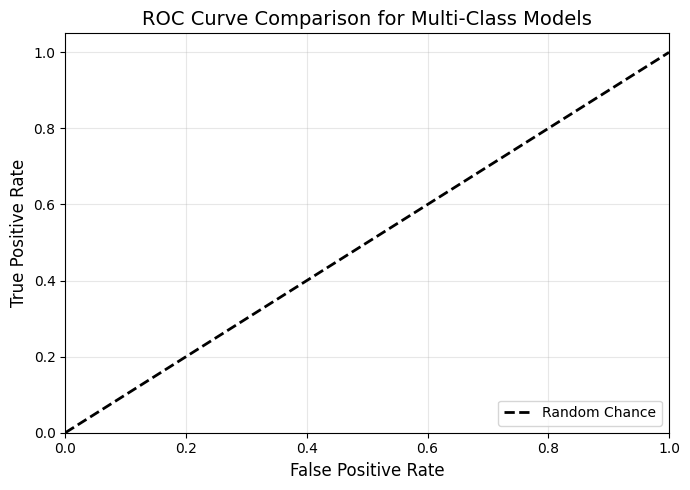

In [34]:
# Multi-class ROC Curve Plotting


plt.figure(figsize=(7, 5))

# Use sampling for faster computation
sample_size = 3000
if len(X_train_mc) > sample_size:
    sample_idx = np.random.choice(len(X_train_mc), sample_size, replace=False)
    X_train_sample = X_train_mc.iloc[sample_idx]
    y_train_sample = y_train_mc.iloc[sample_idx]
else:
    X_train_sample = X_train_mc
    y_train_sample = y_train_mc

# Get unique classes
classes = np.unique(y_test_multi)
n_classes = len(classes)

colors = sns.color_palette("Set2", len(multi_models))

for i, (name, model) in enumerate(multi_models.items()):
    print(f"Processing {name}...")

    try:
        # Train the model on sample
        model.fit(X_train_sample, y_train_sample)

        # Get prediction probabilities
        y_probs = model.predict_proba(X_test_multi)

        # Ensure classes match between training and test
        test_classes = model.classes_

        # Binarize test labels using model's classes
        y_test_bin = label_binarize(y_test_multi, classes=test_classes)

        # Handle case where model may not have all original classes
        if y_test_bin.shape[1] != y_probs.shape[1]:
            print(f"Dimension mismatch for {name}: adjusting...")
            # Skip this model or handle differently
            continue

        # Compute micro-average ROC curve
        if n_classes > 2:
            # Flatten both arrays to same dimensions
            y_test_flat = y_test_bin.ravel()
            y_probs_flat = y_probs.ravel()

            # Make sure dimensions match
            min_len = min(len(y_test_flat), len(y_probs_flat))
            y_test_flat = y_test_flat[:min_len]
            y_probs_flat = y_probs_flat[:min_len]

            fpr_micro, tpr_micro, _ = roc_curve(y_test_flat, y_probs_flat)
            roc_auc_micro = auc(fpr_micro, tpr_micro)

            plt.plot(fpr_micro, tpr_micro,
                     color=colors[i], linewidth=2,
                     label=f'{name} (Micro-avg AUC = {roc_auc_micro:.3f})')
        else:
            # For binary classification
            fpr, tpr, _ = roc_curve(y_test_multi, y_probs[:, 1])
            roc_auc = auc(fpr, tpr)

            plt.plot(fpr, tpr,
                     color=colors[i], linewidth=2,
                     label=f'{name} (AUC = {roc_auc:.3f})')

    except Exception as e:
        print(f"Skipping {name}: {e}")
        continue

# Random chance line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Chance')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison for Multi-Class Models', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
import joblib
import os
from pathlib import Path

# Create directories if they don't exist
base_path = Path('../streamlit_app')
base_path.mkdir(exist_ok=True)

models_path = base_path / 'models'
models_path.mkdir(exist_ok=True)

scalers_path = base_path / 'scalers'
scalers_path.mkdir(exist_ok=True)

# Create subdirectories for CICIDS models
(models_path / 'cicids_binary').mkdir(exist_ok=True)
(models_path / 'cicids_multiclass').mkdir(exist_ok=True)

print("=" * 70)
print("SAVING CICIDS2017 MODELS AND PREPROCESSORS")
print("=" * 70)

# ============= BINARY CLASSIFICATION MODELS =============
print("\n[1/3] Saving CICIDS2017 Binary Classification Models...")

try:
    joblib.dump(models['Logistic Regression'], models_path / 'cicids_binary/logistic_regression.pkl')
    print("✓ Saved: logistic_regression.pkl (Binary)")
except Exception as e:
    print(f"✗ Error saving Logistic Regression (Binary): {e}")

try:
    joblib.dump(models['Decision Tree'], models_path / 'cicids_binary/decision_tree.pkl')
    print("✓ Saved: decision_tree.pkl (Binary)")
except Exception as e:
    print(f"✗ Error saving Decision Tree (Binary): {e}")

try:
    joblib.dump(models['Random Forest'], models_path / 'cicids_binary/random_forest.pkl')
    print("✓ Saved: random_forest.pkl (Binary)")
except Exception as e:
    print(f"✗ Error saving Random Forest (Binary): {e}")

try:
    joblib.dump(models['Gradient Boosting'], models_path / 'cicids_binary/gradient_boosting.pkl')
    print("✓ Saved: gradient_boosting.pkl (Binary)")
except Exception as e:
    print(f"✗ Error saving Gradient Boosting (Binary): {e}")


# ============= MULTI-CLASS CLASSIFICATION MODELS =============
print("\n[2/3] Saving CICIDS2017 Multi-Class Classification Models...")

try:
    joblib.dump(multi_models['Logistic Regression'], models_path / 'cicids_multiclass/logistic_regression.pkl')
    print("✓ Saved: logistic_regression.pkl (Multi-class)")
except Exception as e:
    print(f"✗ Error saving Logistic Regression (Multi-class): {e}")

try:
    joblib.dump(multi_models['Decision Tree'], models_path / 'cicids_multiclass/decision_tree.pkl')
    print("✓ Saved: decision_tree.pkl (Multi-class)")
except Exception as e:
    print(f"✗ Error saving Decision Tree (Multi-class): {e}")

try:
    joblib.dump(multi_models['Random Forest'], models_path / 'cicids_multiclass/random_forest.pkl')
    print("✓ Saved: random_forest.pkl (Multi-class)")
except Exception as e:
    print(f"✗ Error saving Random Forest (Multi-class): {e}")

try:
    joblib.dump(multi_models['Gradient Boosting'], models_path / 'cicids_multiclass/gradient_boosting.pkl')
    print("✓ Saved: gradient_boosting.pkl (Multi-class)")
except Exception as e:
    print(f"✗ Error saving Gradient Boosting (Multi-class): {e}")


# ============= SAVE PREPROCESSOR/SCALER =============
print("\n[3/3] Saving CICIDS2017 Preprocessor...")

preprocessor_data = {
    'scaler': scaler,
    'feature_names': X_train.columns.tolist() if hasattr(X_train, 'columns') else [],
    'dataset_type': 'cicids'
}

try:
    joblib.dump(preprocessor_data, scalers_path / 'cicids_preprocessor.pkl')
    print("✓ Saved: cicids_preprocessor.pkl")
except Exception as e:
    print(f"✗ Error saving preprocessor: {e}")

print("\n" + "=" * 70)
print("MODEL SAVING COMPLETE!")
print("=" * 70)
print(f"\nModels saved to: {models_path.absolute()}")
print(f"Scalers saved to: {scalers_path.absolute()}")



SAVING CICIDS2017 MODELS AND PREPROCESSORS

[1/3] Saving CICIDS2017 Binary Classification Models...
✓ Saved: logistic_regression.pkl (Binary)
✓ Saved: decision_tree.pkl (Binary)
✓ Saved: random_forest.pkl (Binary)
✓ Saved: gradient_boosting.pkl (Binary)

[2/3] Saving CICIDS2017 Multi-Class Classification Models...
✓ Saved: logistic_regression.pkl (Multi-class)
✓ Saved: decision_tree.pkl (Multi-class)
✓ Saved: random_forest.pkl (Multi-class)
✓ Saved: gradient_boosting.pkl (Multi-class)

[3/3] Saving CICIDS2017 Preprocessor...
✓ Saved: cicids_preprocessor.pkl

MODEL SAVING COMPLETE!

Models saved to: /content/../streamlit_app/models
Scalers saved to: /content/../streamlit_app/scalers
